In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter


nltk.download('stopwords', quiet=True) ## contains common words like "the", "is", "and"
nltk.download('wordnet', quiet=True) ## contains the dictionary used by lemmatizer
nltk.download('punkt', quiet=True) ## Sentence/word tokenizer rules
nltk.download('omw-1.4', quiet=True) ## Multilingual wordnet which is used by the lemminizer 

[nltk_data] Downloading package stopwords to C:\Users\shubh
[nltk_data]     bhaskar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Raw Data Review

In [12]:
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True) #Create directories if already not existing

df = pd.read_csv("../raw_data/Deceptive-Review-Detection-main/Chicago_Hotel_Review/Chicago_Hotel_Reviews.csv") 

# Reviewing data
# df   
# print(f"Shape: {df.shape}")                       
# print(f"Column Names: {df.columns.tolist()}")             
# print(f"Data types:- {df.info()}")                       
# print(f"Null Values: {df.isnull().sum()}")    
         

## Exploratory Data Analysis

### Studying Labels

In [13]:
print("Label value counts:-")
print(df['Label'].value_counts())

print("Label proportions:-")
print(df['Label'].value_counts(normalize=True).round(3))  # Expected to be 50-50

Label value counts:-
Label
1    800
0    800
Name: count, dtype: int64
Label proportions:-
Label
1    0.5
0    0.5
Name: proportion, dtype: float64


### Creating word count feature. Studying labels and Rating distribution

In [14]:
df['review_length'] = df['Ori_Review'].apply(lambda x: len(x.split()))

# Rating distribution
print("Rating distribution")
print(df.groupby(['Label', 'Rating']).size().unstack(fill_value = 0)) #multiple columns gotta be presented as a list

## Label distribution
print("Review label distribution")
print(df.groupby('Label')['review_length'].describe()) ## => gives the description based on word count of each label cause we only need that

Rating distribution
Rating    1    5
Label           
0       400  400
1       400  400
Review label distribution
       count       mean        std   min   25%    50%    75%    max
Label                                                              
0      800.0  150.91375  89.813233  30.0  89.0  130.0  183.0  749.0
1      800.0  146.63625  84.788666  25.0  88.0  125.0  182.0  784.0


### Visualization 

C:\Users\shubh bhaskar\AppData\Local\Temp\ipykernel_20192\2797345023.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


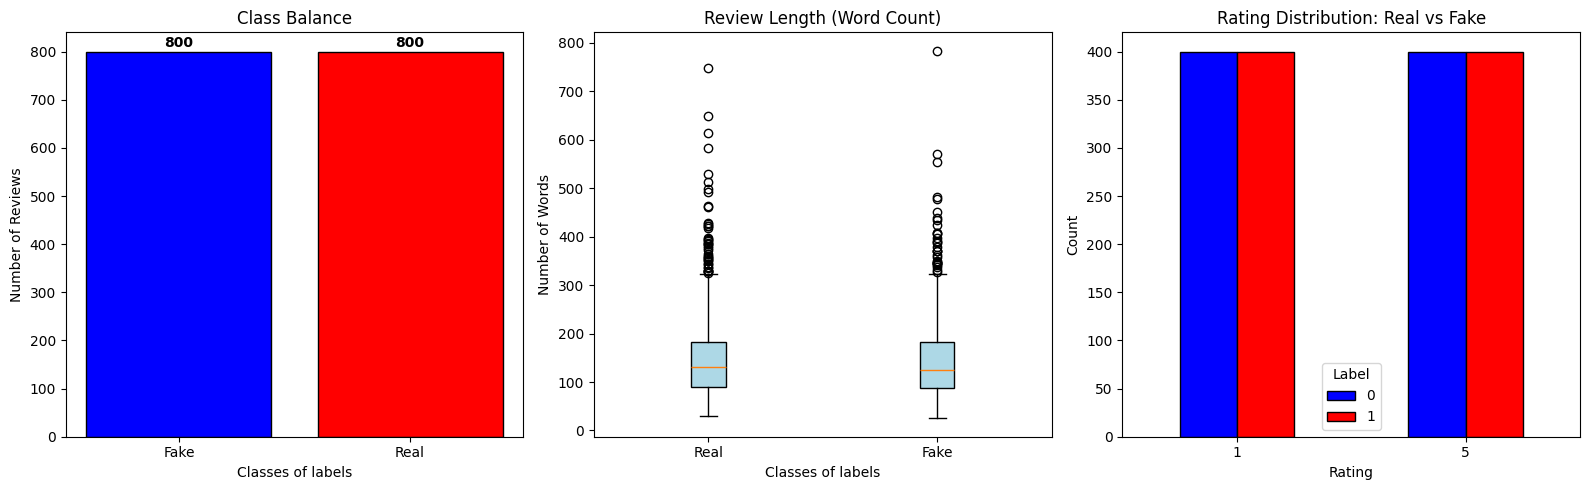

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

## Class imbalance bargraph
label_names = {0: 'Real', 1: 'Fake'}
counts = df['Label'].value_counts()

axes[0].bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color=['blue', 'red'],
    edgecolor='black')

axes[0].set_title("Class Balance")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xlabel("Classes of labels")

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold') #setting v+10 for cleanilness 



## Box plot for Review length distribution (fake vs real)

df['Label_Name'] = df['Label'].map(label_names)
axes[1].boxplot(
    [df[df['Label'] == 0]['review_length'],
     df[df['Label'] == 1]['review_length']],
    labels=['Real', 'Fake'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'))
axes[1].set_title("Review Length (Word Count)")
axes[1].set_xlabel("Classes of labels")
axes[1].set_ylabel("Number of Words")



## Rating distribution by label
rating_data = df.groupby(['Rating', 'Label']).size().unstack(fill_value=0)
rating_data.plot(kind='bar',
    ax=axes[2],
    color=['blue', 'red'],
    edgecolor='black')

axes[2].set_title("Rating Distribution: Real vs Fake")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Count")
axes[2].legend(title="Label")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("plots/eda_plots.png", dpi=150) 
plt.show()

Note: The dataset is small but has a perfect distribution in both ratings and labels. The dataset has no missing values.

## Preprocessing

### Adjusting columns 

In [16]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.rename(columns={"Ori_Review": "review", "Label": "label"})
print(f"Column Names: {df.columns.tolist()}")

Column Names: ['label', 'Rating', 'review', 'review_length', 'Label_Name']


### Cleaning reviews

In [17]:
lemmatizer = WordNetLemmatizer()
stopwords = set(stopwords.words('english'))

negation_words = {"no", "not", "nor", "never", "neither", "without","nobody", "nothing", "nowhere", "hardly", "barely"}
stopwords -= negation_words

def clean_text(text):
    text = text.lower()
    text = re.sub(r"https:/S+|www.S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    tokens = text.split()

    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stopwords and len(word) > 2]

    return " ".join(tokens)

df["clean_review"] = df["review"].apply(clean_text)

# print(f"BEFORE: {df['review'].iloc[5][:100]}")
# print(f"AFTER : {df['clean_review'].iloc[5][:100]}")

### Sanity Check and top 15 words (Real v Fake)

In [18]:
empty_after_clean = df['clean_review'].str.strip().eq('').sum() ## All empty strs will give 1 which adds up to a non zero values

if empty_after_clean != 0:
    raise AssertionError("Review destroyed during cleaning!")

total_words_before = ' '.join(df['review'].str.lower()).split()
total_words_after = ' '.join(df['clean_review']).split()

print(f"Total words before: {len(total_words_before)}")
print(f"Total words after: {len(total_words_after)}")
print(f"removed words/reduction: {(1-(len(total_words_after)/len(total_words_before))) * 100:.2f}%")

Total words before: 238040
Total words after: 116587
removed words/reduction: 51.02%


### Visualizing Fake v Real words

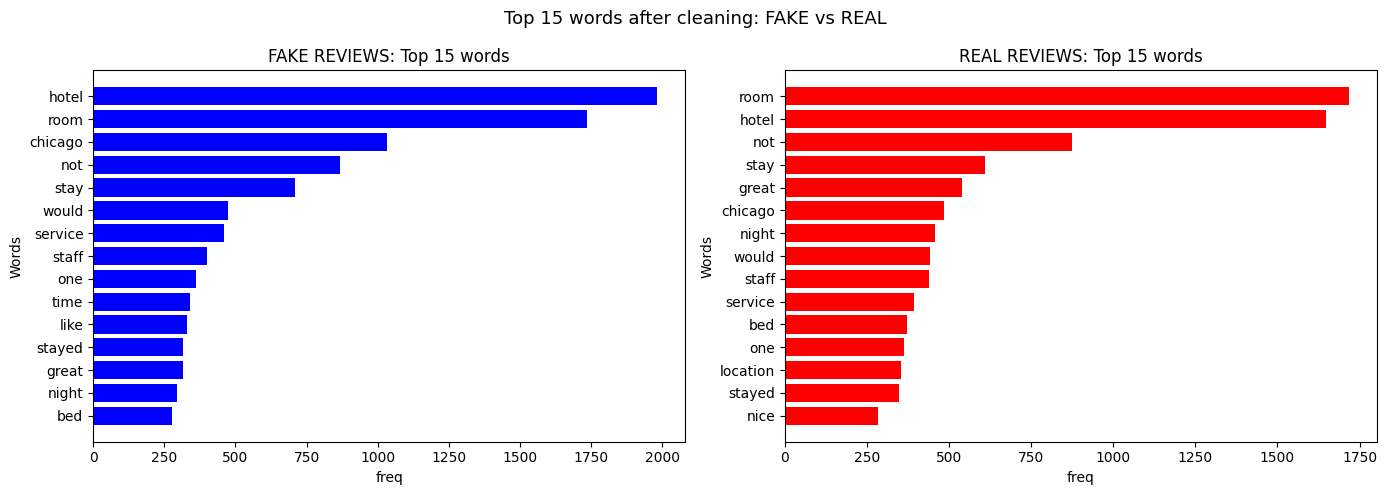

In [19]:
fake_words = ' '.join(df[df['label']==1]['clean_review']).split()
real_words = ' '.join(df[df['label']==0]['clean_review']).split()

fake_counts = Counter(fake_words).most_common(15)
real_counts = Counter(real_words).most_common(15)

## Using bar charts to visualize the word count of top 15 fake and real words

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Top 15 words after cleaning: FAKE vs REAL', fontsize = 13)

new_fake_df = pd.DataFrame(fake_counts, columns= ["Word", "Count"])
new_real_df = pd.DataFrame(real_counts, columns= ["Word", "Count"])

axes[0].barh(new_fake_df['Word'][::-1], new_fake_df['Count'][::-1], color= "blue")
axes[0].set_xlabel('freq')
axes[0].set_ylabel('Words')
axes[0].set_title("FAKE REVIEWS: Top 15 words")

axes[1].barh(new_real_df['Word'][::-1], new_real_df['Count'][::-1], color= "red")
axes[1].set_xlabel('freq')
axes[1].set_ylabel('Words')
axes[1].set_title("REAL REVIEWS: Top 15 words")

plt.tight_layout()
plt.savefig("plots/top_words.png", dpi =120)
plt.show()

## Saving data

In [20]:
os.makedirs("data", exist_ok=True)
df.to_csv("data/cleaned_reviews.csv", index=False)
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['label', 'Rating', 'review', 'review_length', 'Label_Name', 'clean_review']
Shape: (1600, 6)
